In [3]:
import sys
from pathlib import Path

def _find_scripts_dir():
    start = Path.cwd().resolve()
    for base in (start, *start.parents):
        for cand in (base / "scripts", base,
                     *sorted(base.glob("*/scripts")), *sorted(base.glob("*/*/scripts"))):
            if (cand / "project_paths.py").is_file():
                return cand
    raise FileNotFoundError(
        "scripts/project_paths.py not found. Open this notebook from inside the "
        "cloned repository, or point the kernel's working directory at it."
    )

sys.path.insert(0, str(_find_scripts_dir()))
from project_config import *
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import pearsonr
model_df = load_model_df()
y = model_df["phq9"]
assert len(ACOUSTIC) == 72

In [2]:
# Audio robustness experiment 1: drop 10 random recordings/subject, re-run CV.
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

feat = pd.read_csv(EGEMAPS_CSV, dtype={"subject_id": str}).dropna(subset=["phq9"])

N_DROP = 10
rng = np.random.RandomState(SEED)
kept = pd.concat([g.sample(n=len(g) - N_DROP, random_state=rng) if len(g) > N_DROP else g
                  for _, g in feat.groupby("subject_id")])
print("kept recordings/subject:", kept.groupby("subject_id").size().min(),
      "to", kept.groupby("subject_id").size().max())

X_full,    y_full    = subject_means(feat)      # aligned, ACOUSTIC (module)
X_reduced, y_reduced = subject_means(kept)

models = {"RF": RandomForestRegressor(random_state=SEED),
          "GBM": GradientBoostingRegressor(random_state=SEED)}
print(f"\n{'version':10s}{'model':5s}{'R2':>15}{'MAE':>13}{'RMSE':>13}{'r':>13}")
for vname, (X, yy) in {"Full": (X_full, y_full), "Reduced": (X_reduced, y_reduced)}.items():
    for mname, m in models.items():
        r = repeated_cv(m, X, yy)
        fmt = lambda k: f"{r[k][0]:.3f}±{r[k][1]:.3f}"
        print(f"{vname:10s}{mname:5s}{fmt('R2'):>15}{fmt('MAE'):>13}{fmt('RMSE'):>13}{fmt('r'):>13}")


kept recordings/subject: 14 to 19

version   model             R2          MAE         RMSE            r
Full      RF       0.228±0.032  6.282±0.150  7.380±0.152  0.478±0.032
Full      GBM      0.200±0.067  5.978±0.265  7.505±0.313  0.495±0.048
Reduced   RF       0.145±0.039  6.718±0.172  7.766±0.179  0.389±0.043
Reduced   GBM     -0.023±0.092  7.125±0.386  8.488±0.380  0.286±0.076


In [3]:
# Robustness experiment 2
# Adding white Gaussian noise to every resampled WAV at a target SNR -> parallel tree
import numpy as np, soundfile as sf
from pathlib import Path

clean_root = require(RESAMPLED_DIR, "Run the resampling cell in MODMA_audio_processing.ipynb first.")
noisy_root = NOISY_DIR
SNR_DB = 20                        # 20 dB = mild; 10 dB for a harsher test
rng = np.random.RandomState(SEED)  # reproducible noise

wavs = sorted(clean_root.glob("*/*_resampled.wav"))
for wav in wavs:
    y, sr = sf.read(wav)
    p_signal = np.mean(y ** 2)
    if p_signal == 0:              # skip silent files
        continue
    p_noise = p_signal / (10 ** (SNR_DB / 10))
    y_noisy = y + rng.normal(0.0, np.sqrt(p_noise), size=y.shape)
    out = noisy_root / wav.parent.name / wav.name
    out.parent.mkdir(parents=True, exist_ok=True)
    sf.write(out, y_noisy, sr)
print(f"Wrote {len(wavs)} noisy files at SNR={SNR_DB} dB to {noisy_root}")

Wrote 1475 noisy files at SNR=20 dB to C:\Users\zeine\thesis\depression-severity\audio_lanzhou_2015\audio_lanzhou_2015_noisy


In [4]:
# Parse the NOISY eGeMAPS ARFFs -> egemaps_features_noisy.csv
import csv as _csv
from pathlib import Path
import pandas as pd

features_root   = NOISY_DIR             # <-- noisy tree
OUTPUT_FEATURES = EGEMAPS_NOISY_CSV     # <-- new output file

def parse_arff(path: Path) -> dict:
    attributes, data_line, in_data = [], None, False
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            if not in_data:
                low = s.lower()
                if low.startswith("@attribute"):
                    attributes.append(s.split()[1])
                elif low.startswith("@data"):
                    in_data = True
            elif data_line is None:
                data_line = s
    if data_line is None:
        raise ValueError(f"No @data row in {path}")
    values = next(_csv.reader([data_line], quotechar="'"))
    row = {}
    for attr, val in zip(attributes, values):
        if attr in ("name", "class"):
            continue
        row[attr] = pd.NA if val == "?" else float(val)
    return row

# Subject-level clinical data (type, PHQ-9) from the inventory.
inv = pd.read_csv(WAV_INVENTORY, dtype={"subject_id": str})
clinical = (
    inv[["subject_id", "type", "phq9"]]
    .drop_duplicates("subject_id")
    .set_index("subject_id")
)

rows = []
for arff in sorted(features_root.glob("*/egemaps/*_egemaps.*")):
    subject_id = arff.parents[1].name
    recording = arff.stem.replace("_resampled_egemaps", "")
    feats = parse_arff(arff)
    meta = clinical.loc[subject_id] if subject_id in clinical.index else None
    rows.append({
        "subject_id": subject_id,
        "recording": recording,
        "type": meta["type"] if meta is not None else pd.NA,
        "phq9": meta["phq9"] if meta is not None else pd.NA,
        **feats,
    })

features = pd.DataFrame(rows).sort_values(["subject_id", "recording"]).reset_index(drop=True)
features.to_csv(OUTPUT_FEATURES, index=False)
print(f"Parsed {len(features)} noisy ARFF files -> {OUTPUT_FEATURES}")


Parsed 1475 noisy ARFF files -> C:\Users\zeine\thesis\depression-severity\audio_lanzhou_2015\egemaps_features_noisy.csv


In [5]:
# Clean vs Noisy comparison on the 72-feature (collapsed) acoustic set
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Module subject_table: defaults to ACOUSTIC (72) and aligns to CANONICAL_ORDER
versions = {
    "Clean (72)": subject_table("egemaps_features.csv"),
    "Noisy (72)": subject_table("egemaps_features_noisy.csv"),
}
models = {"RF": RandomForestRegressor(random_state=SEED),
          "GBM": GradientBoostingRegressor(random_state=SEED)}

print(f"{'version':12s}{'model':5s}{'R2':>15}{'MAE':>13}{'RMSE':>13}{'r':>13}")
for vname, (X, y) in versions.items():
    for mname, m in models.items():
        r = repeated_cv(m, X, y)                 # module repeated_cv -> {metric:(mean,std)}
        fmt = lambda k: f"{r[k][0]:.3f}±{r[k][1]:.3f}"
        print(f"{vname:12s}{mname:5s}{fmt('R2'):>15}{fmt('MAE'):>13}{fmt('RMSE'):>13}{fmt('r'):>13}")



version     model             R2          MAE         RMSE            r
Clean (72)  RF       0.228±0.032  6.282±0.150  7.380±0.152  0.478±0.032
Clean (72)  GBM      0.200±0.067  5.978±0.265  7.505±0.313  0.495±0.048
Noisy (72)  RF       0.173±0.044  6.512±0.192  7.638±0.199  0.424±0.042
Noisy (72)  GBM      0.013±0.099  6.858±0.375  8.336±0.414  0.345±0.075


In [10]:
# Robustness control: clean -> progressively noisier -> totally random audio
# Endpoint is speech replaced entirely by white noise at the same RMS and duration,
# so the audio carries no vocal information at all. Everything downstream (openSMILE,
# aggregation, CV) is identical to the main pipeline.
import numpy as np, soundfile as sf

def make_audio_tree(out_root, snr_db=None, seed=SEED):
    """snr_db=None -> replace the signal entirely with white noise (same length + RMS).
       snr_db=x    -> add white noise to the real signal at x dB SNR."""
    rng = np.random.RandomState(seed)
    wavs = sorted(RESAMPLED_DIR.glob("*/*_resampled.wav"))
    n = 0
    for wav in wavs:
        sig, sr = sf.read(wav)
        p_signal = np.mean(sig ** 2)
        if p_signal == 0:                      # skip silent files
            continue
        if snr_db is None:
            out_sig = rng.normal(0.0, np.sqrt(p_signal), size=sig.shape)   # no speech left
        else:
            p_noise = p_signal / (10 ** (snr_db / 10))
            out_sig = sig + rng.normal(0.0, np.sqrt(p_noise), size=sig.shape)
        out = out_root / wav.parent.name / wav.name
        out.parent.mkdir(parents=True, exist_ok=True)
        sf.write(out, out_sig, sr)
        n += 1
    return n

CONDITIONS = [            # (label, snr_db, directory)
    ("SNR 20 dB",     20,   DATA_DIR / "audio_snr20"),
    ("SNR 10 dB",     10,   DATA_DIR / "audio_snr10"),
    ("SNR 5 dB",       5,   DATA_DIR / "audio_snr05"),
    ("SNR 0 dB",       0,   DATA_DIR / "audio_snr00"),
    ("SNR -5 dB",     -5,   DATA_DIR / "audio_snr-05"),
    ("Random audio", None,  DATA_DIR / "audio_random"),
]

for label, snr, root in CONDITIONS:
    n = make_audio_tree(root, snr_db=snr)
    print(f"{label:14s} -> {n} files in {root.name}")


SNR 20 dB      -> 1475 files in audio_snr20
SNR 10 dB      -> 1475 files in audio_snr10
SNR 5 dB       -> 1475 files in audio_snr05
SNR 0 dB       -> 1475 files in audio_snr00
SNR -5 dB      -> 1475 files in audio_snr-05
Random audio   -> 1475 files in audio_random


In [5]:
# Parse each condition's openSMILE ARFFs -> one per-recording feature table.
import csv as _csv
import pandas as pd

CONDITIONS = [            # (label, snr_db, directory)
    ("SNR 20 dB",     20,   DATA_DIR / "audio_snr20"),
    ("SNR 10 dB",     10,   DATA_DIR / "audio_snr10"),
    ("SNR 5 dB",       5,   DATA_DIR / "audio_snr05"),
    ("SNR 0 dB",       0,   DATA_DIR / "audio_snr00"),
    ("SNR -5 dB",     -5,   DATA_DIR / "audio_snr-05"),
    ("Random audio", None,  DATA_DIR / "audio_random"),
]


def parse_arff(path):
    attributes, data_line, in_data = [], None, False
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            if not in_data:
                low = s.lower()
                if low.startswith("@attribute"):
                    attributes.append(s.split()[1])
                elif low.startswith("@data"):
                    in_data = True
            elif data_line is None:
                data_line = s
    if data_line is None:
        raise ValueError(f"No @data row in {path}")
    values = next(_csv.reader([data_line], quotechar="'"))
    return {a: (pd.NA if v == "?" else float(v))
            for a, v in zip(attributes, values) if a not in ("name", "class")}

inv = pd.read_csv(WAV_INVENTORY, dtype={"subject_id": str})
clinical = inv[["subject_id", "type", "phq9"]].drop_duplicates("subject_id").set_index("subject_id")

def build_feature_table(features_root, out_csv):
    rows = []
    for arff in sorted(features_root.glob("*/egemaps/*_egemaps.*")):
        sid = arff.parents[1].name
        meta = clinical.loc[sid] if sid in clinical.index else None
        rows.append({"subject_id": sid,
                     "recording": arff.stem.replace("_resampled_egemaps", ""),
                     "type": meta["type"] if meta is not None else pd.NA,
                     "phq9": meta["phq9"] if meta is not None else pd.NA,
                     **parse_arff(arff)})
    feats = pd.DataFrame(rows).sort_values(["subject_id", "recording"]).reset_index(drop=True)
    feats.to_csv(out_csv, index=False)
    n_nan = feats[ACOUSTIC].isna().all().sum()
    print(f"  {len(feats):5d} recordings -> {out_csv.name}"
          f"{f'   [{n_nan} all-NaN features]' if n_nan else ''}")
    return out_csv

for label, snr, root in CONDITIONS:
    build_feature_table(root, DATA_DIR / f"egemaps_{root.name}.csv")


   1475 recordings -> egemaps_audio_snr20.csv
   1475 recordings -> egemaps_audio_snr10.csv
   1475 recordings -> egemaps_audio_snr05.csv
   1475 recordings -> egemaps_audio_snr00.csv
   1475 recordings -> egemaps_audio_snr-05.csv
   1475 recordings -> egemaps_audio_random.csv


In [7]:
# ===== Trend + baseline =====
# White noise has no voiced frames, so openSMILE returns '?' for F0/jitter/shimmer/HNR
# on the random-audio condition. Impute inside the CV pipeline so every condition is
# scored by the same estimator and no fold sees imputation from its own test rows.
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

def rf_pipe():
    return Pipeline([("impute", SimpleImputer(strategy="mean")),
                     ("rf",     RandomForestRegressor(random_state=SEED))])

X_clean, y_clean = subject_table("egemaps_features.csv")

rows = []
r = repeated_cv(rf_pipe(), X_clean, y_clean)
rows.append({"condition": "Clean", "snr_db": np.inf, "R2": r["R2"][0], "MAE": r["MAE"][0]})

for label, snr, root in CONDITIONS:
    X, yy = subject_table(f"egemaps_{root.name}.csv")
    r = repeated_cv(rf_pipe(), X, yy)
    rows.append({"condition": label, "snr_db": -np.inf if snr is None else snr,
                 "R2": r["R2"][0], "MAE": r["MAE"][0]})

b = repeated_cv(DummyRegressor(strategy="mean"), X_clean, y_clean)
rows.append({"condition": "Baseline (mean predictor)", "snr_db": np.nan,
             "R2": b["R2"][0], "MAE": b["MAE"][0]})

curve = pd.DataFrame(rows)
print(curve.round(4).to_string(index=False))
curve.to_csv(DATA_DIR / "audio_noise_curve.csv", index=False)


                condition  snr_db      R2    MAE
                    Clean     inf  0.2276 6.2824
                SNR 20 dB    20.0  0.1725 6.5124
                SNR 10 dB    10.0  0.1260 6.7743
                 SNR 5 dB     5.0  0.1184 6.8653
                 SNR 0 dB     0.0  0.1046 6.9725
                SNR -5 dB    -5.0  0.0544 7.2313
             Random audio    -inf -0.0526 7.3966
Baseline (mean predictor)     NaN -0.0442 7.9802


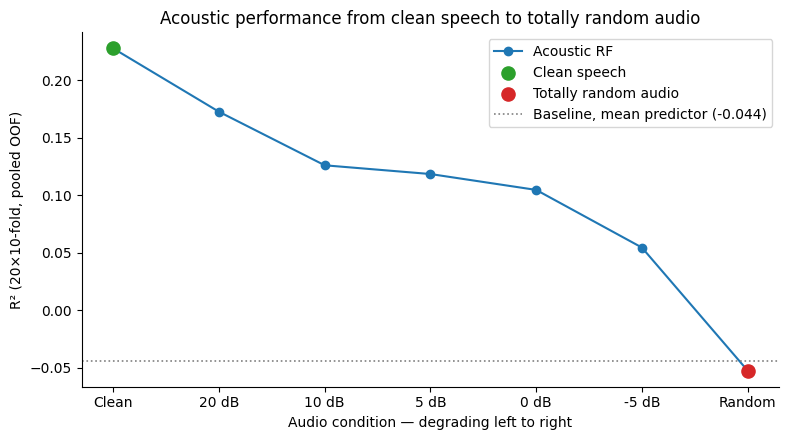

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Everything except the baseline row (the only one with snr_db = NaN), ordered
# by SNR descending: Clean (inf) -> 20 -> 10 -> 5 -> 0 -> -5 -> Random (-inf).
pts   = curve[curve["snr_db"].notna()].sort_values("snr_db", ascending=False).reset_index(drop=True)
basel = curve.loc[curve["condition"].str.startswith("Baseline"), "R2"].iloc[0]
x     = np.arange(len(pts))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, pts["R2"], marker="o", color="#1f77b4", zorder=2, label="Acoustic RF")

# Endpoints marked separately -- they are qualitatively different from the SNR sweep
ax.scatter(x[0],  pts["R2"].iloc[0],  s=90, color="#2ca02c", zorder=3, label="Clean speech")
ax.scatter(x[-1], pts["R2"].iloc[-1], s=90, color="#d62728", zorder=3, label="Totally random audio")

ax.axhline(basel, color="gray", ls=":", lw=1.2,
           label=f"Baseline, mean predictor ({basel:.3f})")

ax.set_xticks(x)
ax.set_xticklabels(pts["condition"].str.replace("SNR ", "", regex=False)
                                   .str.replace(" audio", "", regex=False))
ax.set_xlabel("Audio condition — degrading left to right")
ax.set_ylabel("R² (20×10-fold, pooled OOF)")
ax.set_title("Acoustic performance from clean speech to totally random audio")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "audio_noise_curve.png", dpi=300, bbox_inches="tight")
plt.show()


In [6]:
# Psych robustness experiment 1: drop GAD-7 from the modelled psych set
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

psych_drop = [c for c in PSYCH if c != "gad7"]     # perturbation: GAD-7 removed
rf = RandomForestRegressor(random_state=SEED)

full = repeated_cv(rf, model_df[PSYCH], y)         # {metric: (mean, sd)} across 20 seeds
drop = repeated_cv(rf, model_df[psych_drop], y)

rows = []
for metric in ["MAE", "RMSE", "R2", "r"]:
    o, o_sd = full[metric]
    p, p_sd = drop[metric]
    pct = float("nan") if abs(o) < 1e-9 else round(
        100 * ((p - o) if metric in ("MAE", "RMSE") else (o - p)) / abs(o), 1)
    rows.append({"metric": metric,
                 "original":  round(o, 3), "original_sd":  round(o_sd, 3),
                 "perturbed": round(p, 3), "perturbed_sd": round(p_sd, 3),
                 "delta": round(p - o, 3),          # MAE/RMSE up = worse, R2/r down = worse
                 "pct_worse": pct,                  # positive = degraded
                 "exceeds_noise": abs(p - o) > max(o_sd, p_sd)})

comp = pd.DataFrame(rows)

print(f"Psych set: {PSYCH} ({len(PSYCH)}) -> dropping GAD-7 -> {psych_drop} ({len(psych_drop)})  [RF]")
print(comp.to_string(index=False))

worst = comp.loc[comp["pct_worse"].idxmax()]
flag = "" if worst["exceeds_noise"] else "  [within fold-split noise]"
print(f"\nMost degraded: {worst['metric']} {worst['pct_worse']}% "
      f"({worst['original']} -> {worst['perturbed']}){flag}")


Psych set: ['ctq_sf', 'LES', 'SSRS', 'gad7'] (4) -> dropping GAD-7 -> ['ctq_sf', 'LES', 'SSRS'] (3)  [RF]
metric  original  original_sd  perturbed  perturbed_sd  delta  pct_worse  exceeds_noise
   MAE     2.622        0.122      6.124         0.218  3.502      133.5           True
  RMSE     3.956        0.169      7.717         0.234  3.762       95.1           True
    R2     0.778        0.019      0.155         0.051 -0.623       80.1           True
     r     0.884        0.010      0.456         0.038 -0.428       48.4           True

Most degraded: MAE 133.5% (2.622 -> 6.124)


In [9]:
# Psych robustness experiment 2: random partial missingness (MCAR) + median imputation
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X_psych = model_df[PSYCH].astype(float)

MISSING_FRACS = [0.0, 0.1, 0.2, 0.3, 0.5]     # 0.0 = original baseline
N_DRAWS = 27 

def add_missing(X, frac, seed):
    """Set a random `frac` of cells to NaN (missing completely at random)."""
    if frac == 0.0:
        return X
    return X.mask(np.random.RandomState(seed).rand(*X.shape) < frac)

rows = []
for frac in MISSING_FRACS:
    for d in range(1 if frac == 0.0 else N_DRAWS):
        Xm = add_missing(X_psych, frac, SEED + 1000 * d + int(frac * 100))
        # median imputation refit inside every CV fold -> no leakage
        pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                         ("rf",  RandomForestRegressor(random_state=SEED))])
        res = repeated_cv(pipe, Xm, y)
        rows.append({"missing_%": int(frac * 100), "draw": d,
                     **{k: res[k][0] for k in ["MAE", "RMSE", "R2", "r"]}})

comp = (pd.DataFrame(rows).groupby("missing_%", as_index=False)
        .agg(MAE=("MAE", "mean"), RMSE=("RMSE", "mean"), R2=("R2", "mean"),
             R2_sd=("R2", "std"), r=("r", "mean"), n_draws=("draw", "count")).round(3))

print(f"Psych set: {PSYCH} ({len(PSYCH)} scales), RF, {N_DRAWS} mask draw(s) per level")
print(comp.to_string(index=False))

base  = comp[comp["missing_%"] == 0].iloc[0]
worst = comp[comp["missing_%"] == int(MISSING_FRACS[-1] * 100)].iloc[0]
print(f"\nDegradation at {int(worst['missing_%'])}% missing vs 0% (positive = worse):")
for k in ["MAE", "RMSE", "R2", "r"]:
    o, p = base[k], worst[k]
    pct = np.nan if abs(o) < 1e-9 else round(100 * ((p - o) if k in ("MAE", "RMSE") else (o - p)) / abs(o), 1)
    print(f"  {k:5s}: {o:7.3f} -> {p:7.3f}   ({pct:+.1f}%)")


Psych set: ['ctq_sf', 'LES', 'SSRS', 'gad7'] (4 scales), RF, 27 mask draw(s) per level
 missing_%   MAE  RMSE    R2  R2_sd     r  n_draws
         0 2.622 3.956 0.778    NaN 0.884        1
        10 3.322 4.888 0.656  0.085 0.813       27
        20 3.746 5.368 0.585  0.093 0.768       27
        30 4.530 6.213 0.444  0.135 0.672       27
        50 5.145 6.824 0.331  0.142 0.593       27

Degradation at 50% missing vs 0% (positive = worse):
  MAE  :   2.622 ->   5.145   (+96.2%)
  RMSE :   3.956 ->   6.824   (+72.5%)
  R2   :   0.778 ->   0.331   (+57.5%)
  r    :   0.884 ->   0.593   (+32.9%)


In [8]:
# Experiments 1 & 2 for Demographics and Clinical
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

feature_sets = {"Demographics": DEMO, "Clinical": CLINICAL}

def rf():
    return RandomForestRegressor(random_state=SEED)

def pct_worse(metric, base, pert):
    """Positive = degraded. MAE/RMSE up is worse; R2/r down is worse."""
    if abs(base) < 1e-9:
        return float("nan")
    return round(100 * ((pert - base) if metric in ("MAE", "RMSE") else (base - pert)) / abs(base), 1)

def worst_of(deg):
    return max(deg, key=lambda k: deg[k] if deg[k] == deg[k] else -np.inf)

def top_feature(cols):
    """Most important feature by MDI on the full sample."""
    m = RandomForestRegressor(random_state=SEED).fit(model_df[cols], y)
    return pd.Series(m.feature_importances_, index=cols).idxmax()

# ---------- Experiment 1: drop the most important feature by MDI ----------
print("=== EXPERIMENT 1: drop most-important feature (RF) ===")
for sname, cols in feature_sets.items():
    drop_feat = top_feature(cols)
    reduced   = [c for c in cols if c != drop_feat]
    base = repeated_cv(rf(), model_df[cols], y)
    pert = repeated_cv(rf(), model_df[reduced], y)
    deg  = {k: pct_worse(k, base[k][0], pert[k][0]) for k in ["MAE", "RMSE", "R2", "r"]}
    w    = worst_of(deg)
    print(f"{sname:12s} drop '{drop_feat}':  "
          f"R2 {base['R2'][0]:.3f}->{pert['R2'][0]:.3f}  "
          f"MAE {base['MAE'][0]:.3f}->{pert['MAE'][0]:.3f}  | most degraded: {w} ({deg[w]}%)")

# ---------- Experiment 2: random partial missingness (MCAR) + imputation ----------
print("\n=== EXPERIMENT 2: random missingness (RF, median imputation inside each fold) ===")
MISSING_FRACS = [0.0, 0.1, 0.2, 0.3, 0.5]
N_DRAWS = 27

def add_missing(X, frac, seed):
    if frac == 0.0:
        return X
    return X.mask(np.random.RandomState(seed).rand(*X.shape) < frac)

rows = []
for sname, cols in feature_sets.items():
    X = model_df[cols].astype(float)
    for frac in MISSING_FRACS:
        for d in range(1 if frac == 0.0 else N_DRAWS):
            Xm   = add_missing(X, frac, SEED + 1000 * d + int(frac * 100))
            pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("rf", rf())])
            res  = repeated_cv(pipe, Xm, y)
            rows.append({"set": sname, "missing_%": int(frac * 100), "draw": d,
                         **{k: res[k][0] for k in ["MAE", "RMSE", "R2", "r"]}})

miss = (pd.DataFrame(rows).groupby(["set", "missing_%"], as_index=False)
        .agg(MAE=("MAE", "mean"), RMSE=("RMSE", "mean"), R2=("R2", "mean"),
             R2_sd=("R2", "std"), r=("r", "mean")).round(3))
print(miss.to_string(index=False))

HEAVIEST = int(MISSING_FRACS[-1] * 100)
print(f"\nDegradation at {HEAVIEST}% missing vs 0%:")
for sname in feature_sets:
    b = miss[(miss["set"] == sname) & (miss["missing_%"] == 0)].iloc[0]
    w_ = miss[(miss["set"] == sname) & (miss["missing_%"] == HEAVIEST)].iloc[0]
    deg = {k: pct_worse(k, b[k], w_[k]) for k in ["MAE", "RMSE", "R2", "r"]}
    w = worst_of(deg)
    print(f"  {sname:12s} R2 {b['R2']:.3f}->{w_['R2']:.3f}  most degraded: {w} ({deg[w]}%)")


=== EXPERIMENT 1: drop most-important feature (RF) ===
Demographics drop 'age':  R2 0.188->0.183  MAE 5.964->5.899  | most degraded: r (4.2%)
Clinical     drop 'gad7':  R2 0.764->0.338  MAE 2.660->5.319  | most degraded: MAE (100.0%)

=== EXPERIMENT 2: random missingness (RF, median imputation inside each fold) ===
         set  missing_%   MAE  RMSE     R2  R2_sd     r
    Clinical          0 2.660 4.073  0.764    NaN 0.876
    Clinical         10 3.180 4.686  0.684  0.076 0.828
    Clinical         20 3.703 5.229  0.605  0.103 0.779
    Clinical         30 4.252 5.828  0.510  0.123 0.715
    Clinical         50 5.188 6.781  0.337  0.166 0.590
Demographics          0 5.964 7.564  0.188    NaN 0.495
Demographics         10 6.328 7.994  0.090  0.102 0.414
Demographics         20 6.706 8.316  0.015  0.114 0.338
Demographics         30 6.840 8.490 -0.026  0.124 0.293
Demographics         50 7.437 8.846 -0.113  0.117 0.165

Degradation at 50% missing vs 0%:
  Demographics R2 0.188->-0.113 

In [ ]:
# ===== Robustness summary: original vs perturbed, all modalities =====
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def rf_pipe():
    """Median imputation is fit per training fold -- required for the missingness rows."""
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("rf",  RandomForestRegressor(random_state=SEED))])

def avg_draws(results):
    """Average a list of repeated_cv dicts, keeping the {metric: (mean, sd)} shape."""
    return {k: (float(np.mean([r[k][0] for r in results])),
                float(np.mean([r[k][1] for r in results]))) for k in results[0]}

N_DRAWS, MISS_FRAC = 3, 0.30
records = []

def add(modality, perturbation, orig, pert):
    (r2o, r2o_sd), (maeo, _) = orig["R2"], orig["MAE"]
    (r2p, r2p_sd), (maep, _) = pert["R2"], pert["MAE"]
    records.append({
        "modality": modality, "perturbation": perturbation,
        "R2_orig": round(r2o, 3), "R2_pert": round(r2p, 3),
        "R2_deg_%": np.nan if abs(r2o) < 1e-9 else round(100 * (r2o - r2p) / abs(r2o), 1),
        "MAE_orig": round(maeo, 3), "MAE_pert": round(maep, 3),
        "MAE_deg_%": round(100 * (maep - maeo) / maeo, 1),
        "exceeds_noise": bool(abs(r2o - r2p) > max(r2o_sd, r2p_sd)),
    })

# --- Clinical-family perturbations: drop-top-feature & 30% missingness ---
for name, cols in {"Demographics": DEMO, "Psych": PSYCH, "Clinical": CLINICAL}.items():
    orig = repeated_cv(rf_pipe(), model_df[cols], y)

    top = pd.Series(RandomForestRegressor(random_state=SEED)
                    .fit(model_df[cols], y).feature_importances_, index=cols).idxmax()
    add(name, f"drop '{top}'", orig,
        repeated_cv(rf_pipe(), model_df[[c for c in cols if c != top]], y))

    X = model_df[cols].astype(float)
    draws = [repeated_cv(rf_pipe(),
                         X.mask(np.random.RandomState(SEED + 1000 * d).rand(*X.shape) < MISS_FRAC), y)
             for d in range(N_DRAWS)]
    add(name, f"{int(MISS_FRAC * 100)}% missing", orig, avg_draws(draws))

# --- Acoustic perturbations: drop-10-recordings & noise ---
feat = pd.read_csv(EGEMAPS_CSV, dtype={"subject_id": str}).dropna(subset=["phq9"])
Xa, ya  = subject_means(feat)                      # aligned to CANONICAL_ORDER, ACOUSTIC
orig_ac = repeated_cv(rf_pipe(), Xa, ya)

rec_rng = np.random.RandomState(SEED)              # own stream: independent of the masks above
kept = pd.concat([g.sample(n=max(len(g) - 10, 1), random_state=rec_rng)
                  for _, g in feat.groupby("subject_id")])
Xd, yd = subject_means(kept)
add("Acoustic", "drop 10 recordings", orig_ac, repeated_cv(rf_pipe(), Xd, yd))

if EGEMAPS_NOISY_CSV.exists():
    Xn, yn = subject_table(EGEMAPS_NOISY_CSV)
    add("Acoustic", "noise (SNR)", orig_ac, repeated_cv(rf_pipe(), Xn, yn))
else:
    print("(noisy features not found yet — skipping the noise row)")

# --- Table ---
summary = pd.DataFrame(records)
print(summary.to_string(index=False))
summary.to_csv(DATA_DIR / "robustness_summary.csv", index=False)

# --- Per-perturbation comparison. NOT averaged across modalities: the clinical
# family and the acoustic family are subjected to different stressors, so a single
# "most stable modality" number would compare incomparable things.
print("\nR2 degradation by perturbation (lower = more stable):")
for pert, grp in summary.groupby("perturbation", sort=False):
    line = "  ".join(f"{r.modality} {r['R2_deg_%']:+.1f}%"
                     f"{'' if r.exceeds_noise else '(ns)'}" for _, r in grp.iterrows())
    print(f"  {pert:22s} {line}")
print("\n(ns) = change smaller than the run-to-run SD of the estimate")


    modality       perturbation  R2_orig  R2_pert  R2_deg_%  MAE_orig  MAE_pert  MAE_deg_%
Demographics         drop 'age'    0.188    0.183       2.3     5.964     5.899       -1.1
Demographics        30% missing    0.188    0.057      69.8     5.964     6.408        7.4
       Psych        drop 'gad7'    0.805    0.722      10.3     2.561     3.196       24.8
       Psych        30% missing    0.805    0.641      20.4     2.561     3.874       51.3
    Clinical        drop 'gad7'    0.784    0.700      10.7     2.663     3.304       24.1
    Clinical        30% missing    0.784    0.558      28.8     2.663     4.013       50.7
    Acoustic drop 10 recordings    0.228    0.143      37.4     6.282     6.756        7.5
    Acoustic        noise (SNR)    0.228    0.173      24.2     6.282     6.512        3.7

Mean R2 degradation by modality (lower = more stable):
modality
Psych           15.4
Clinical        19.8
Acoustic        30.8
Demographics    36.0

Most stable: Psych  |  Least st